# Panel local projections: CPI on xi x oil

This notebook is a notebook-first version of the panel local-projections workflow.

It is designed so you can:

- change horizons, lag lengths, and fixed effects interactively,
- start with `cpi_pct_change` on `xi_x_oil`,
- add country-year controls later by editing a small `panel_controls` list,
- optionally trim CPI outliers with an IQR rule before estimation,
- inspect the base panel before we promote the workflow into a full CLI pipeline.


In [10]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

for path in [ROOT, ROOT / "src"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import local_projections as lp


In [ ]:
xi_path = ROOT / "data/processed/xi/regular/xi_by_country_year.parquet"
cpi_path = ROOT / "data/processed/cpi/quarterly_cpi.csv"
oil_path = ROOT / "data/processed/oil/quarterly_oil.csv"
cpi_freq = "Q"

# Add future controls here. These are merged into the panel.
# Example:
# panel_controls = [
#     {
#         "name": "exchange_rate",
#         "path": ROOT / "data/processed/exchange_rates/quarterly_exchange_rates.csv",
#         "value_column": "log_diff",
#         "merge_keys": ["country", "period"],
#         "merge_key_columns": {"country": "country_code", "period": "quarter"},
#         "status_column": None,
#     }
# ]
panel_controls = [
    {
        "name": "exchange_rate",
        "path": ROOT / "data/processed/exchange_rates/quarterly_exchange_rates.csv",
        "value_column": "log_diff",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"country": "country_code", "period": "quarter"},
        "status_column": None,
    },
    {
        "name": "output_gap",
        "path": ROOT / "data/processed/real_gdp/quarterly_output_gap.csv",
        "value_column": "output_gap",
        "merge_keys": ["country", "period"],
        "status_column": "hp_filter_status",
        "ok_status": "ok",
    },
    {
        "name": "policy_rate",
        "path": ROOT / "data/processed/policy_rates/quarterly_policy_rates.csv",
        "value_column": "policy_rate",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"period": "quarter"},
        "status_column": None,
    }
]

# Controls that actually enter the LP regression.
regression_controls = ["exchange_rate", "output_gap", "policy_rate"]

horizons = 11
y_lags = 3
shock_lags = 3
control_lags = {"exchange_rate": 3, "output_gap": 3, "policy_rate": 3}
include_country_fe = True
include_year_fe = True
cov_type = "cluster_country_time"
common_sample = True
remove_cpi_outliers = False
iqr_multiplier = 10
exclude_countries = []
sample_start = None
sample_end = None
lag_xi_by_one_year_for_xi_x_oil = True

print("horizons:", horizons)
print("y_lags:", y_lags)
print("shock_lags:", shock_lags)
print("control_lags:", control_lags)
print("include_country_fe:", include_country_fe)
print("include_year_fe:", include_year_fe)
print("cov_type:", cov_type)
print("common_sample:", common_sample)
print("remove_cpi_outliers:", remove_cpi_outliers)
print("iqr_multiplier:", iqr_multiplier)
print("panel_controls:", [spec["name"] for spec in panel_controls])
print("regression_controls:", regression_controls)
print("lag_xi_by_one_year_for_xi_x_oil:", lag_xi_by_one_year_for_xi_x_oil)


horizons: 11
y_lags: 3
shock_lags: 3
control_lags: {'exchange_rate': 3, 'output_gap': 3, 'policy_rate': 3}
include_country_fe: True
include_year_fe: True
cov_type: cluster_country_time
common_sample: True
remove_cpi_outliers: False
iqr_multiplier: 10
panel_controls: ['exchange_rate', 'output_gap', 'policy_rate']
regression_controls: ['exchange_rate', 'output_gap', 'policy_rate']
lag_xi_by_one_year_for_xi_x_oil: True


In [12]:
panel_df = lp.build_panel_lp_dataset(
    xi_path=xi_path,
    cpi_path=cpi_path,
    oil_path=oil_path,
    cpi_freq=cpi_freq,
    lag_xi_by_one_year_for_xi_x_oil=lag_xi_by_one_year_for_xi_x_oil,
    controls=panel_controls,
    exclude_countries=exclude_countries,
    sample_start=sample_start,
    sample_end=sample_end,
)

diag_df = lp.panel_diagnostics(panel_df)
diag_df


,rows,countries,year_min,year_max,avg_years_per_country,period_min,period_max,avg_periods_per_country
0,4470,40,1995,2022,27.95,1995-Q1,2022-Q4,111.75


In [13]:
panel_df.head()


,country,year,period,time_index,xi,oil_pct_change,xi_x_oil,cpi_pct_change,exchange_rate,output_gap,policy_rate
0,AUS,1995,1995-Q1,7980,0.021698,0.043415,NaN,0.015924,0.008404,-0.002764,7.5
1,AUS,1995,1995-Q2,7981,0.021698,0.051642,NaN,0.014106,0.028409,-0.007747,7.5
2,AUS,1995,1995-Q3,7982,0.021698,-0.097255,NaN,0.012365,-0.017450,0.005223,7.5
3,AUS,1995,1995-Q4,7983,0.021698,0.026433,NaN,0.007634,-0.010554,-0.004938,7.5
4,AUS,1996,1996-Q1,7984,0.024256,0.079017,0.001714,0.003030,-0.010226,0.000280,7.5


In [14]:
panel_df_model = panel_df.copy()

if remove_cpi_outliers:
    q1 = panel_df_model["cpi_pct_change"].quantile(0.25)
    q3 = panel_df_model["cpi_pct_change"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - iqr_multiplier * iqr
    upper = q3 + iqr_multiplier * iqr
    panel_df_model = panel_df_model.loc[
        panel_df_model["cpi_pct_change"].between(lower, upper)
    ].copy()
    print(f"CPI IQR fence: [{lower:.6f}, {upper:.6f}]")
    print("Rows after CPI outlier filter:", len(panel_df_model))
    print("Dropped rows:", len(panel_df) - len(panel_df_model))
else:
    print("CPI outlier filter disabled.")
    print("Rows kept:", len(panel_df_model))

panel_df_model.head()


CPI outlier filter disabled.
Rows kept: 4470


,country,year,period,time_index,xi,oil_pct_change,xi_x_oil,cpi_pct_change,exchange_rate,output_gap,policy_rate
0,AUS,1995,1995-Q1,7980,0.021698,0.043415,NaN,0.015924,0.008404,-0.002764,7.5
1,AUS,1995,1995-Q2,7981,0.021698,0.051642,NaN,0.014106,0.028409,-0.007747,7.5
2,AUS,1995,1995-Q3,7982,0.021698,-0.097255,NaN,0.012365,-0.017450,0.005223,7.5
3,AUS,1995,1995-Q4,7983,0.021698,0.026433,NaN,0.007634,-0.010554,-0.004938,7.5
4,AUS,1996,1996-Q1,7984,0.024256,0.079017,0.001714,0.003030,-0.010226,0.000280,7.5


In [15]:
irf_df, coef_df, models = lp.fit_panel_local_projections(
    panel_df_model,
    y_col="cpi_pct_change",
    shock_col="xi_x_oil",
    horizons=horizons,
    y_lags=y_lags,
    shock_lags=shock_lags,
    controls=regression_controls,
    control_lags=control_lags,
    include_country_fe=include_country_fe,
    include_year_fe=include_year_fe,
    cov_type=cov_type,
    common_sample=common_sample,
)

irf_df


c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value 

,horizon,term,coef,std_err_cluster_country_time,t,p_value,ci_low_95,ci_high_95,nobs,n_countries
0,0,xi_x_oil,-0.056103,0.073580,-0.762472,0.445779,-0.200317,0.088112,3010.0,39
1,1,xi_x_oil,-0.043678,0.052683,-0.829073,0.407063,-0.146934,0.059578,3010.0,39
2,2,xi_x_oil,-0.024372,0.079401,-0.306944,0.758886,-0.179995,0.131252,3010.0,39
3,3,xi_x_oil,0.034503,0.030319,1.137973,0.255132,-0.024922,0.093927,3010.0,39
4,4,xi_x_oil,-0.005122,0.065840,-0.077789,0.937996,-0.134165,0.123922,3010.0,39
5,5,xi_x_oil,-0.069685,0.047989,-1.452094,0.146475,-0.163742,0.024372,3010.0,39
6,6,xi_x_oil,0.003387,0.056122,0.060350,0.951877,-0.106610,0.113384,3010.0,39
7,7,xi_x_oil,-0.002154,0.054504,-0.039521,0.968475,-0.108980,0.104672,3010.0,39
8,8,xi_x_oil,-0.077734,0.062629,-1.241185,0.214537,-0.200485,0.045017,3010.0,39
9,9,xi_x_oil,-0.065947,0.059098,-1.115894,0.264468,-0.181777,0.049883,3010.0,39


In [16]:
coef_df.loc[coef_df["term"].isin(["xi_x_oil", "const"])].head(10)


,horizon,term,coef,std_err_cluster_country_time,t,p_value,ci_low_95,ci_high_95,nobs
0,0,const,0.003636,0.001985,1.831723,6.699268e-02,-0.000255,0.007526,3010.0
1,0,xi_x_oil,-0.056103,0.073580,-0.762472,4.457786e-01,-0.200317,0.088112,3010.0
148,1,const,0.007510,0.001221,6.149901,7.753112e-10,0.005116,0.009903,3010.0
149,1,xi_x_oil,-0.043678,0.052683,-0.829073,4.070629e-01,-0.146934,0.059578,3010.0
296,2,const,0.006421,0.001695,3.787593,1.521139e-04,0.003098,0.009743,3010.0
297,2,xi_x_oil,-0.024372,0.079401,-0.306944,7.588857e-01,-0.179995,0.131252,3010.0
444,3,const,0.008008,0.001604,4.992934,5.946892e-07,0.004865,0.011152,3010.0
445,3,xi_x_oil,0.034503,0.030319,1.137973,2.551318e-01,-0.024922,0.093927,3010.0
592,4,const,0.005357,0.001205,4.446097,8.744444e-06,0.002996,0.007719,3010.0
593,4,xi_x_oil,-0.005122,0.065840,-0.077789,9.379962e-01,-0.134165,0.123922,3010.0


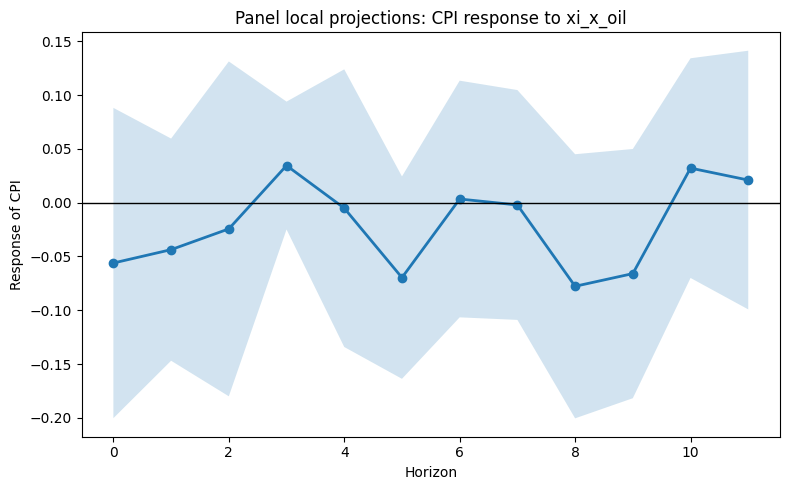

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
lp.plot_irf(irf_df, ax=ax)
plt.tight_layout()
plt.show()


In [18]:
horizon_to_inspect = 0
print(models[horizon_to_inspect].summary())


                             OLS Regression Results                             
Dep. Variable:     cpi_pct_change_lead0   R-squared:                       0.523
Model:                              OLS   Adj. R-squared:                  0.499
Method:                   Least Squares   F-statistic:                     46.37
Date:                  Sun, 05 Apr 2026   Prob (F-statistic):           1.88e-24
Time:                          17:19:32   Log-Likelihood:                 11043.
No. Observations:                  3010   AIC:                        -2.179e+04
Df Residuals:                      2862   BIC:                        -2.090e+04
Df Model:                           147                                         
Covariance Type:                cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const         